In [1]:
import gzip
import pickle 
import matplotlib
matplotlib.rc('font', size=15)
import numpy as np
import torch 
import pandas as pd
import numpy as np
import plotly.express as px
import sys
sys.path.append("/afs/cern.ch/work/m/mgarciam/private/mlpf/")
from scipy.optimize import linear_sum_assignment
import numpy as np
import matplotlib.pyplot as plt

/afs/cern.ch/work/m/mgarciam/private/miniconda/miniconda3/envs/graphgps0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import awkward as ak
import numpy as np
outputs = ak.from_parquet("/eos/experiment/fcc/users/m/mgarciam/mlpf/condor/test/3/out_reco_edm4hep_REC.parquet")
# for i in range(0,100):
#     if np.round(outputs["X_gen"][i][0,8],0)==12:
#         print(outputs["X_gen"][i][0,8])
#         print(i)

In [10]:
idx = 3
bcm = outputs["ygen_hit_before_cm"][idx]
afc = outputs["ygen_hit_calm"][idx]
nidx = outputs["ygen_hit"][idx]
mask = bcm==16
print(bcm[mask])
print(afc[mask])
print(nidx[mask])

[16, 16, 16, 16, 16, 16, 16, 16, 16, ..., 16, 16, 16, 16, 16, 16, 16, 16, 16]
[16, 16, 16, 16, 16, 16, 16, 16, 16, ..., 16, 16, 16, 16, 16, 16, 16, 16, 16]
[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..., 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


In [34]:
e_over_true_list= []
e_list = []
list_paths = ! ls /eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/train/Z_uds_CLD_o2_v05_eval_v1/05/pf_tree_*.parquet
eta_list = []
track_exist=[]
R_track = []
for j in list_paths[0:40]:
    print(j)
    outputs = ak.from_parquet(j)
    import numpy as np
    for i in range(0,100):
        id = outputs["ygen_track"][i]
        mask = id!=-1
        p_track = outputs["X_track"][i][:,5]
        p_t = p_track[mask]
        id_good = id[mask]
        p_true = outputs["X_gen"][i][id_good][:,11]
        e_over_true = p_t/p_true
        e = p_true
        # e_over_true_list.append(np.array(e_over_true))
       
        # eta_list.append(np.array(outputs["X_gen"][i][id_good][:,5]))

        pdg_mask = np.abs(outputs["X_gen"][i][:,0])==211
        ids_with_track = np.arange(0, len(outputs["X_gen"][i][:,0]), 1)[pdg_mask]
        track_exist.append(np.array(np.in1d(ids_with_track, outputs["ygen_track"][0]))*1)
        vertex_id = np.array(outputs["X_gen"][i][:,[15,16,17]]) #15,16,17
        R = np.sqrt(np.sum(vertex_id**2, axis=1))
        e_list.append(np.array(outputs["X_gen"][i][:,11])[pdg_mask])
        R_track.append(R[pdg_mask])
e_list = np.concatenate(e_list)
R_track = np.concatenate(R_track)
track_exist = np.concatenate(track_exist)


/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/train/Z_uds_CLD_o2_v05_eval_v1/05/pf_tree_10002.parquet
/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/train/Z_uds_CLD_o2_v05_eval_v1/05/pf_tree_10003.parquet
/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/train/Z_uds_CLD_o2_v05_eval_v1/05/pf_tree_10004.parquet
/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/train/Z_uds_CLD_o2_v05_eval_v1/05/pf_tree_10005.parquet
/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/train/Z_uds_CLD_o2_v05_eval_v1/05/pf_tree_10006.parquet
/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/train/Z_uds_CLD_o2_v05_eval_v1/05/pf_tree_10007.parquet
/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/train/Z_uds_CLD_o2_v05_eval_v1/05/pf_tree_10008.parquet
/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/train/Z_uds_CLD_o2_v05_eval_v1/05/pf_tree_10009.parquet
/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/train/Z_uds_CLD_o2_v05_eval_v1/05/pf_tree_10010.parquet
/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/train/Z_uds_CLD_o2_v05_eval_v1/05/pf

Text(0.5, 0, 'R vertex')

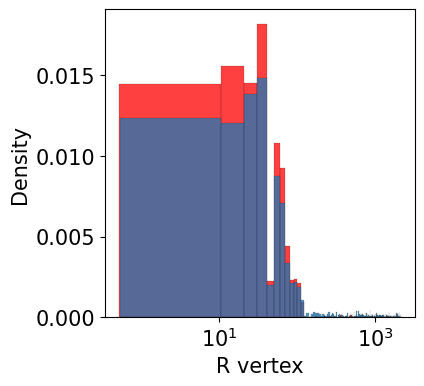

In [44]:
import seaborn as sns
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot()
sns.histplot(R_track[(track_exist==1)*(e_list>10)],stat="density", color="r", binwidth=10)
sns.histplot(R_track[(track_exist==0)*(e_list>10)],stat="density", binwidth=10)
# plt.xlim([0,200])
ax.set_xscale('log')
plt.xlabel("R vertex")
# import seaborn as sns
# sns.histplot(e_list[(track_exist==1)*(e_list>10)],stat="density", color="r", binwidth=0.1)
# sns.histplot(e_list[track_exist==0],stat="density", binwidth=0.1)
# ax.set_xscale('log')


In [45]:
R

array([  27.64823995,   27.64823995,   27.64823995,   27.64823995,
         27.64825726,   27.64825726,   27.64845491,   27.64845491,
         27.64823995,   27.64823995,   27.64823995,   27.64823995,
         27.64823995,   27.64874866,   27.64824738,   27.64824738,
         27.64824518,   27.64824518,   27.64822063,   27.64822063,
         27.64092036,   70.519036  , 1981.04930849, 1993.99621506,
        175.16186237, 1864.62653677, 1215.67508823, 1215.67508823,
       1215.67508823, 1215.67508823, 2137.07537028,  562.65145622,
        562.65145622])

In [92]:
bins = [0,0.5,2,5,10,15,20,70]
import sys
sys.path.append("/afs/cern.ch/work/m/mgarciam/private/mlpf/")
number_bins = 3000 

bins_per_binned_E = np.linspace(0, 2, number_bins)
distributions = []
sigma_E = []
mean_E = []
low_list = []
high_list = []
for i in range(len(bins) - 1):
    bin_i = bins[i]
    bin_i1 = bins[i + 1]
    mask_above = e_list <= bin_i1
    mask_below = e_list > bin_i
    mask_above_eta = eta_list <= 0.36
    mask_below_eta = eta_list > -0.36
    
    
    if np.sum(mask) > 0:  # if the bin is not empty
        e_over_true = e_over_true_list[mask_above*mask_below]
       
        distributions.append(e_over_true)

        bins_per_binned_E = np.linspace(0, 2, number_bins)
        mean_predtotrue, var_predtotrue, low, high = obtain_MPV_and_68(e_over_true,bins_per_binned_E, no_divide=True, epsilon=0.1)
        # print(len(e_over_true), mean_predtotrue, var_predtotrue, var_predtotrue/mean_predtotrue)
        sigma_E.append(var_predtotrue)
        mean_E.append(mean_predtotrue)
        low_list.append(low)
        high_list.append(high)


std 0.02934311437145709 0.9619873291097032 1.0206735578526174
std 0.008336112037345744 0.9893297765921973 1.0060020006668888
std 0.00633544514838269 0.991997332444148 1.0046682227409134
std 0.006668889629876551 0.9913304434811603 1.0046682227409134
std 0.006668889629876551 0.9926642214071357 1.0060020006668888
std 0.006335445148382746 0.9933311103701233 1.0060020006668888
std 0.006002000666888829 0.9926642214071357 1.0046682227409134


In [83]:
from src.utils.inference.inference_metrics import get_std68
def obtain_MPV_and_68(data_for_hist, bins_per_binned_E, epsilon=0.01, no_divide=False):
    hist, bin_edges = np.histogram(data_for_hist, bins=bins_per_binned_E, density=True)
    ind_max_hist = np.argmax(hist)
    MPV = (bin_edges[ind_max_hist] + bin_edges[ind_max_hist + 1]) / 2
    std68, low, high = get_std68(hist, bin_edges, epsilon=epsilon)
    print("std", std68, low, high)
    if std68 == 0.4 and low == 0.2 and high == 1.0:
        print("not able to use tsd68")
        # It didn't fit correctly as it's too close to a delta function
        if type(data_for_hist) == pd.Series:
            data_for_hist = data_for_hist.values
        MPV, std68 = torch.mean(torch.tensor(data_for_hist)).item(), torch.std(torch.tensor(data_for_hist)).item()
    if no_divide:
        return MPV, std68, low, high
    return MPV, std68 / MPV, low, high

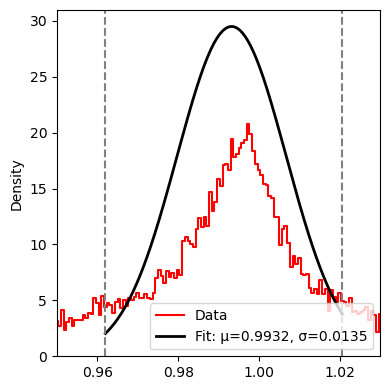

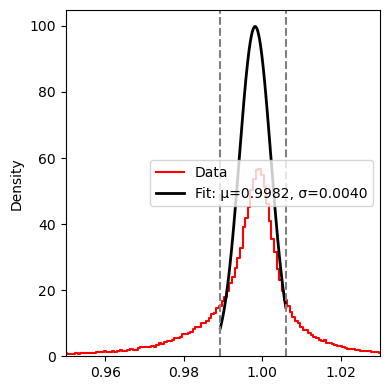

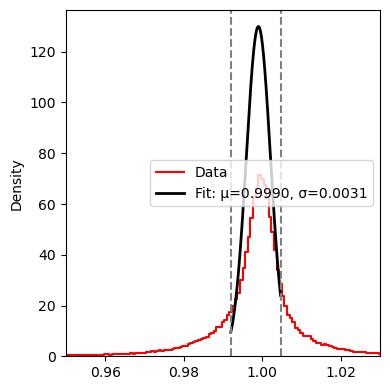

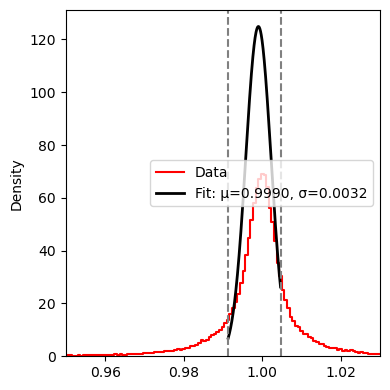

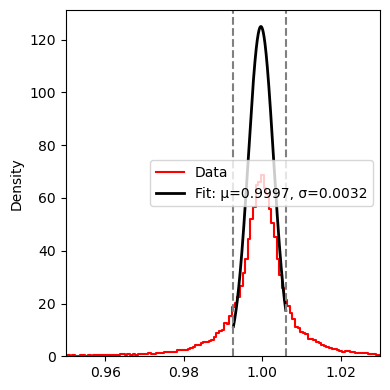

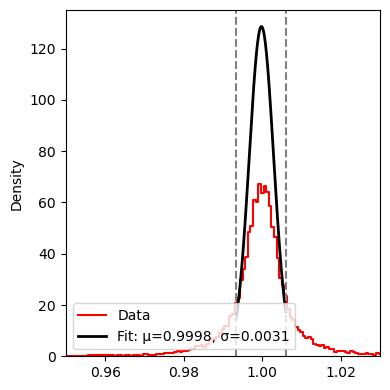

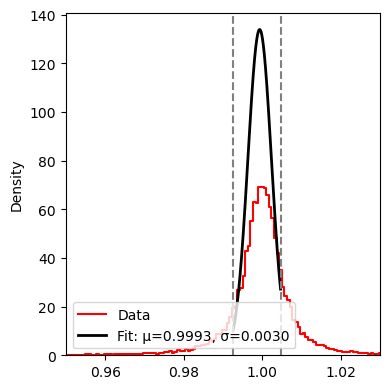

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

number_dist = len(distributions)

for i in range(number_dist):
    data = np.asarray(distributions[i])
    # Select range
    low = low_list[i]
    high = high_list[i]
    mask = (data >= low) & (data <= high)
    data_fit = data[mask]
    # Gaussian fit (MLE)
    mu, sigma = norm.fit(data_fit)
    # Plot
    fig = plt.figure(figsize=(4, 4))
    sns.histplot(
        data,
        bins=np.linspace(0, 2, 3000),
        element="step",
        fill=False,
        stat="density",
        color="red",
        label="Data"
    )
    x = np.linspace(low, high, 1000)
    y = norm.pdf(x, mu, sigma)
    plt.plot(x, y, color="black", lw=2, label=f"Fit: μ={mu:.4f}, σ={sigma:.4f}")
    plt.axvline(low, color="gray", linestyle="--")
    plt.axvline(high, color="gray", linestyle="--")
    plt.xlim([0.95, 1.03])
    plt.legend()
    plt.tight_layout()
    plt.show()


In [90]:
(np.array(high_list)-np.array(low_list))/2

array([0.00700233, 0.00666889, 0.00666889, 0.00733578, 0.00666889,
       0.00633545])

In [77]:
distributions[0]

array([1.00514942, 0.99917528, 0.99946521, ..., 0.99866001, 0.97835993,
       0.9987965 ])

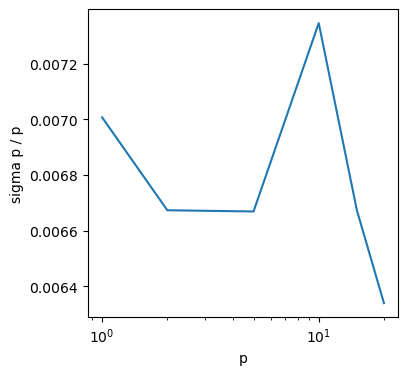

In [74]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))

plt.plot(bins[:-1], np.array(sigma_E)/np.array(mean_E))
plt.xlabel("p")
plt.ylabel("sigma p / p")
plt.xscale("log")

In [5]:
masses= []
for i in range(0,100):
    momentum_i = outputs["X_gen"][i][:,12:15]
    energy = outputs["X_gen"][i][:,8]
    mass = outputs["X_gen"][i][:,10]
    momentum_i= np.array(momentum_i)
    x =momentum_i[:,0]
    y =momentum_i[:,1]
    z =momentum_i[:,2]
    m=np.sqrt(np.sum(energy)**2-np.sum(momentum_i)**2)
    masses.append(m)

In [6]:
masses

[90.63034864186447,
 87.41716489544713,
 88.85205032235923,
 89.61716402457078,
 87.6712120435842,
 91.09350222012499,
 90.17135453953566,
 88.11046134917285,
 91.70240136739775,
 89.89527078913315,
 91.10193313104612,
 90.48653316220435,
 92.63611803835737,
 90.14398909463046,
 91.8823808870908,
 91.0373794873405,
 90.75383667928598,
 92.50737048123611,
 92.60250278916762,
 88.56509308923354,
 91.45193154365587,
 90.41817064376804,
 88.98670121044576,
 90.90708210106128,
 90.09484027277996,
 90.38230459780827,
 91.54631612536296,
 90.39234604933104,
 91.05458485563786,
 90.54536611678897,
 90.16130759546522,
 85.75985775117505,
 91.08480739959667,
 92.17041246321156,
 92.54783708088142,
 90.00449163699028,
 87.7075093685065,
 94.81927897225972,
 88.31573141877108,
 86.07571189669477,
 91.84319590727003,
 89.67354191273377,
 91.42907420234073,
 89.40465149360794,
 93.84473443139969,
 89.97416445856086,
 89.5015098073902,
 88.45102501076093,
 92.97700017091246,
 89.06518643804435,
 90.4

In [60]:
np.where(np.abs(outputs["X_gen"][id][:,0])==11)

(<Array [29, 30] type='2 * int64'>,)

In [61]:

outputs["ygen_track"][id]

<Array [-1, 4, 0, 5, -1, 8, -1, -1] type='8 * int64'>

In [8]:
outputs1["X_gen"][0][:,8]

<Array [1.34, 3.53, 27.3, 4.14, ..., 0.99, 1.6, 0.349] type='33 * float64'>

In [22]:
outputs["ygen_track"][1]


<Array [21, 2, 6, 1, 18, 7, -1, ..., 8, -1, 2, 30, 1, -1, 22] type='15 * int64'>

In [13]:
import numpy as np
np.array(outputs["ygen_track"][1])

array([-2112.,  -211.,  -321.,    22.,    22.,    22.,  -211.,   211.,
        -211.,    22.,    22.,   130.,    22.,    22.,    22.,    22.,
          22.,    22.,  -211.,  2112.,   211.,  -211.,   211.,    22.,
          22.,    22.,    11.,    22.,    22.,    22.,  -211.,   211.,
         -11.])

In [101]:
outputs["pfo_calohit"][0]

<Array [3, 3, 0, 3, 3, 0, 3, 3, ..., 3, 3, 11, 3, 3, 3, 3] type='2781 * int64'>

In [37]:
#"/eos/experiment/fcc/ee/datasets/DC_tracking/Pythia_evaluation/Zcard/reco_Zcard_1.root"
datasets = {
    "test": "/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/eval/Zuds_2025_09_29_key4hep_20250529_CLD_r20250526/pf_tree_50002.parquet",
    "train": "/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/eval/Zuds_2025_09_29_key4hep_20250529_CLD_r20250526/pf_tree_50002.parquet"
}
from src.utils.utils import to_filelist
from src.dataset.dataset import SimpleIterDataset
class Args:
    def __init__(self, datasets):
        self.data_train = [datasets]
        self.data_val = [datasets]
        #self.data_train = files_train
        self.data_config = '/afs/cern.ch/work/m/mgarciam/private/mlpf/config_files/config_hits_track_v4.yaml'
        self.extra_selection = None
        self.train_val_split = 1
        self.data_fraction = 1
        self.file_fraction = 1
        self.fetch_by_files = False
        self.fetch_step = 1
        self.steps_per_epoch = None
        self.in_memory = False
        self.local_rank = None
        self.copy_inputs = False
        self.no_remake_weights = False
        self.batch_size = 1
        self.num_workers = 0
        self.demo = False
        self.laplace = False
        self.diffs = False
        self.class_edges = False


args = {key: Args(value) for key, value in datasets.items()}

datas = {}
files_dict = {}
for key in datasets:
    train_range = (0, args[key].train_val_split)
    train_file_dict, train_files = to_filelist(args[key], 'val')
    train_data = SimpleIterDataset(train_file_dict, args[key].data_config, for_training=False,
                                   extra_selection=args[key].extra_selection,
                                   remake_weights=True,
                                   load_range_and_fraction=(train_range, args[key].data_fraction),
                                   file_fraction=args[key].file_fraction,
                                   fetch_by_files=args[key].fetch_by_files,
                                   fetch_step=args[key].fetch_step,
                                   infinity_mode=False,
                                   in_memory=args[key].in_memory,
                                   async_load=False,
                                   name='train')
    datas[key] = train_data
    files_dict[key] = train_files

['/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/eval/Zuds_2025_09_29_key4hep_20250529_CLD_r20250526/pf_tree_50002.parquet']


['/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/eval/Zuds_2025_09_29_key4hep_20250529_CLD_r20250526/pf_tree_50002.parquet']


In [60]:
itera = iter(train_data)

=== Restarting DataIter train, seed=None ===
Start fetching next batch, len(filelist)=1, load_range=(0, 1)


In [61]:
g,y = next(itera)

In [62]:
g.ndata['pandora_pfo'].shape, torch.sum(g.ndata['pandora_pfo']==-1)

(torch.Size([2793]), tensor(5))

In [96]:
torch.sum(g.ndata['pandora_pfo']==0)

tensor(517)

In [97]:
outputs["X_pandora"][0]

<Array [[-211, -0.853, 0.417, ..., 1.15, 1.36], ...] type='17 * var * float64'>

In [100]:

import pandas as pd
import plotly.express as px

mask = (g.ndata['pandora_pfo']==0)
tidx =  1*(g.ndata['particle_number'][mask].view(-1,1))
#tidx =    1*(g.ndata['hit_link_modified'][mask].view(-1,1))+1
features =  20*(g.ndata['e_hits'][mask].view(-1,1)) + 1*g.ndata["h"][mask][:,-1].view(-1,1)
X = g.ndata["pos_hits_xyz"][mask] #[mask]
data = {
            "X":X[:, 0].view(-1, 1).detach().cpu().numpy(),
            "Y": X[:, 1].view(-1, 1).detach().cpu().numpy(),
            "Z": X[:, 2].view(-1, 1).detach().cpu().numpy(),
            "tIdx": tidx.view(-1, 1).detach().cpu().numpy(),
            "features": features.view(-1, 1).detach().cpu().numpy(),
        }
hoverdict = {}
# if hoverfeat is not None:
#     for j in range(hoverfeat.shape[1]):
#         hoverdict["f_" + str(j)] = hoverfeat[:, j : j + 1]
#     data.update(hoverdict)

# if nidx is not None:
#     data.update({"av_same": av_same})

df = pd.DataFrame(
np.concatenate([data[k] for k in data], axis=1),
columns=[k for k in data],
)
rdst = np.random.RandomState(1234567890)  # all the same
# shuffle_truth_colors(df, "tIdx", rdst)

hover_data = ["tIdx"] #+ [k for k in hoverdict.keys()]
# if nidx is not None:
#     hover_data.append("av_same")
fig = px.scatter_3d(
df,
x="X",
y="Y",
z="Z",
color="tIdx",
size="features",
hover_data=hover_data,
template="simple_white",
)
fig.update_traces(marker=dict(line=dict(width=0)))